# Extension of Diversity Vector to Narrative Diversity (D_narr)

-> Sentiment trajectory divergence across stories

**Approach:** 
- For each story extract a normalized sentiment arc
- Per-sentence sentiment from the transformer classifier `siebert/sentiment-roberta-large-english`
- Binned into 10 equal-proportion narrative segments and averaged per segment 
- Narrative diversity per prompt-source group via mean pairwise Euclidean distance between arcs

**Reference:** Reagan et al. (2016) — The emotional arcs of stories are dominated by six basic shapes (theoretical framing but we do not reproduce their lexicon-based sentiment scoring.)

**Dataset:** `human_drift` — 100 prompts × 10 stories × 5 sources × 2 tasks

**Metric formula:**
$$D_{\text{narr}} = \frac{1}{\binom{n}{2}} \sum_{i < j} \| \mathbf{a}_i - \mathbf{a}_j \|_2$$
where $\mathbf{a}_i$ is the binned sentiment arc of story $i$.

In [1]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import seaborn as sns
from pathlib import Path
from itertools import combinations
from scipy.stats import kruskal
import nltk
from nltk.tokenize import sent_tokenize
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Download NLTK punkt tokenizer
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

In [3]:
# Configuration
# Number of points to bin each sentiment arc into
ARC_LENGTH = 10

# Minimum sentences required to include a story (must be >= ARC_LENGTH so every bin has >=1 sentence)
MIN_SENTENCES = 10

# Minimum valid stories required for a (prompt, source) group to be included in aggregate statistics
MIN_STORIES_PER_GROUP = 5


TASK_FILTER = 'storytelling'

SOURCES = ['human', 'llama', 'mistral', 'qwen', 'gemma']
SOURCE_COLORS = {
    'human': '#1565C0', 'llama': '#E65100',
    'mistral': '#6A1B9A', 'qwen': '#2E7D32', 'gemma': '#C62828',
}

print("Configuration:")
print(f"  Arc length (bins):               {ARC_LENGTH}")
print(f"  Minimum sentences per story:     {MIN_SENTENCES}")
print(f"  Minimum stories per group:       {MIN_STORIES_PER_GROUP}")
print(f"  Task filter:                     {TASK_FILTER}")

Configuration:
  Arc length (bins):               10
  Minimum sentences per story:     10
  Minimum stories per group:       5
  Task filter:                     storytelling


## Load Dataset

In [4]:
REPO_DIR = Path('../../data/human_drift')
N_PROMPTS = 100

texts = {}

# Load texts (100 prompts per source)
for source in SOURCES:
    fp = REPO_DIR / 'clean_generations' / f'{source}_storytelling_clean.json'
    with open(fp) as f:
        raw = json.load(f)
    prompts = list(raw.keys())[:N_PROMPTS]
    texts[source] = {i: raw[p] for i, p in enumerate(prompts)}

# Load baseline distances
with open(REPO_DIR / 'drift_analysis' / 'per_input_distances.json') as f:
    per_input_3d = json.load(f)

baseline_3d = {}
for source in SOURCES:
    sem = per_input_3d[source]['storytelling']['semantic']
    lex = per_input_3d[source]['storytelling']['lexical']
    syn = per_input_3d[source]['storytelling']['syntactic']
    baseline_3d[source] = np.column_stack([sem, lex, syn])

total = sum(len(texts[s][p]) for s in SOURCES for p in texts[s])
expected = len(SOURCES) * N_PROMPTS * 10
print(f"{total:,} texts loaded  (missing: {expected - total})")
print()
print(f'{"Source":10s}  {"Prompts":>7}  {"Texts":>6}  {"Missing":>7}')
print("-" * 60)
for source in SOURCES:
    n_texts = sum(len(texts[source][p]) for p in texts[source])
    n_prompts = len(texts[source])
    missing = n_prompts * 10 - n_texts
    incomplete = [(p, len(texts[source][p])) for p in texts[source] if len(texts[source][p]) < 10]
    print(f"{source:10s}  {n_prompts:>7}  {n_texts:>6}  {missing:>7}")
    for p, cnt in incomplete:
        print(f"  -> Prompt {p}: {cnt} texts")
print("-" * 60)

# Baseline distances per source
print()
print("Baseline distances:")
for source in SOURCES:
    means = baseline_3d[source].mean(axis=0)
    print(f'  {source:8s}: Sem={means[0]:.3f}, Lex={means[1]:.3f}, Syn={means[2]:.3f}')

4,994 texts loaded  (missing: 6)

Source      Prompts   Texts  Missing
------------------------------------------------------------
human           100    1000        0
llama           100    1000        0
mistral         100    1000        0
qwen            100     994        6
  -> Prompt 16: 9 texts
  -> Prompt 30: 9 texts
  -> Prompt 52: 9 texts
  -> Prompt 58: 9 texts
  -> Prompt 78: 9 texts
  -> Prompt 90: 9 texts
gemma           100    1000        0
------------------------------------------------------------

Baseline distances:
  human   : Sem=0.666, Lex=0.985, Syn=0.805
  llama   : Sem=0.352, Lex=0.937, Syn=0.692
  mistral : Sem=0.287, Lex=0.936, Syn=0.671
  qwen    : Sem=0.345, Lex=0.959, Syn=0.704
  gemma   : Sem=0.343, Lex=0.958, Syn=0.685


In [5]:
# Convert nested texts dict to a flat DataFrame
rows = []
for source in SOURCES:
    for prompt_id, story_list in texts[source].items():
        for text in story_list:
            rows.append({
                'source': source,
                'prompt_id': prompt_id,
                'text': text
            })

df = pd.DataFrame(rows)

print(f"DataFrame shape: {df.shape}")
print(df.head())

DataFrame shape: (4994, 3)
  source  prompt_id                                               text
0  human          0  The wet marble floor pressed on his cheek like...
1  human          0  Year after year the Oscar had eluded DiCaprio....
2  human          0  Leo stood there in perfect silence. The hushed...
3  human          0  'Well?' \n \n'Well what?' \n \n'Is it real?' \...
4  human          0  *Blart 3D Gets Lost in the Food Court* | July ...


## Compute Sentiment Arcs

In [9]:
# Transformer-based sentiment analysis (siebert/sentiment-roberta-large-english)

# DEVICE is forced to CPU: the PyTorch MPS backend hung/crashed repeatedly on this 
# machine during batched .to(device) transfers for this model

'''
import torch
from transformers import pipeline

SENTIMENT_MODEL = 'siebert/sentiment-roberta-large-english'
DEVICE = -1  # forced CPU
BATCH_SIZE = 32

sentiment_pipe = pipeline('sentiment-analysis', model=SENTIMENT_MODEL, device=DEVICE, truncation=True)
print(f"Loaded {SENTIMENT_MODEL} on device={DEVICE}")


def tokenize_sentences(text: str, min_sentences: int = MIN_SENTENCES):
    """
    Sentence-tokenize and drop very short fragments. 
    Returns None if below min_sentences
    """
    sentences = sent_tokenize(text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 5]
    if len(sentences) < min_sentences:
        return None
    return sentences


def bin_to_arc(scores, arc_length: int = ARC_LENGTH):
    """
    Split per-sentence sentiment scores into `arc_length` contiguous, roughly equal-sized
    narrative segments and average each segment. Requires len(scores) >= arc_length so
    every bin gets at least one real sentence (enforced via MIN_SENTENCES >= ARC_LENGTH).
    """
    bins = np.array_split(np.asarray(scores), arc_length)
    return np.array([b.mean() for b in bins])


def score_sentences_batch(sentences, batch_size=BATCH_SIZE):
    """
    Score a flat list of sentences with the transformer.
    Returns a continuous signed score in [-1, 1]
    """
    results = sentiment_pipe(sentences, batch_size=batch_size)

    # Convert to continuous signed score in [-1, 1]: 2*P(positive) - 1
    # This ensures that a 50/50-uncertain sentence scores ~0
    p_positive = np.array([r['score'] if r['label'] == 'POSITIVE' else 1 - r['score'] for r in results])
    return 2 * p_positive - 1


# Tokenize all texts, then batch-score every sentence in the corpus in one pass
df['sentences'] = df['text'].apply(tokenize_sentences)
df_tok = df.dropna(subset=['sentences']).copy()

flat_sentences, row_ids = [], []
for idx, sents in zip(df_tok.index, df_tok['sentences']):
    flat_sentences.extend(sents)
    row_ids.extend([idx] * len(sents))

print(f"Scoring {len(flat_sentences):,} sentences ...")
flat_scores = score_sentences_batch(flat_sentences)

scores_by_row = {}
for rid, score in zip(row_ids, flat_scores):
    scores_by_row.setdefault(rid, []).append(score)

df_tok['sentiment_arc'] = df_tok.index.map(lambda i: bin_to_arc(scores_by_row[i]))
df_valid = df_tok.drop(columns=['sentences']).reset_index(drop=True)

n_valid = len(df_valid)
n_invalid = len(df) - n_valid
print(f"Valid arcs:   {n_valid}")
print(f"Skipped (too short): {n_invalid}")
'''

'\nimport torch\nfrom transformers import pipeline\n\nSENTIMENT_MODEL = \'siebert/sentiment-roberta-large-english\'\nDEVICE = -1  # forced CPU\nBATCH_SIZE = 32\n\nsentiment_pipe = pipeline(\'sentiment-analysis\', model=SENTIMENT_MODEL, device=DEVICE, truncation=True)\nprint(f"Loaded {SENTIMENT_MODEL} on device={DEVICE}")\n\n\ndef tokenize_sentences(text: str, min_sentences: int = MIN_SENTENCES):\n    """\n    Sentence-tokenize and drop very short fragments. \n    Returns None if below min_sentences\n    """\n    sentences = sent_tokenize(text)\n    sentences = [s.strip() for s in sentences if len(s.strip()) > 5]\n    if len(sentences) < min_sentences:\n        return None\n    return sentences\n\n\ndef bin_to_arc(scores, arc_length: int = ARC_LENGTH):\n    """\n    Split per-sentence sentiment scores into `arc_length` contiguous, roughly equal-sized\n    narrative segments and average each segment. Requires len(scores) >= arc_length so\n    every bin gets at least one real sentence (en

In [10]:
# Save the valid DataFrame with sentiment arcs to a pickle file for later use
# df_valid.to_pickle('df_valid_transformer.pkl')

### Visualize Example Arcs

In [11]:
df_valid = pd.read_pickle('df_valid_transformer.pkl')

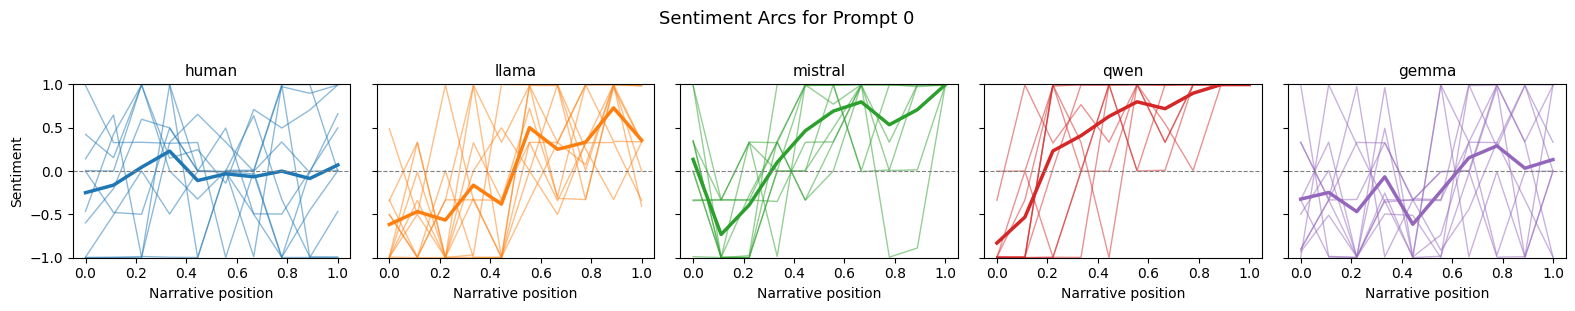

In [12]:
# Show sentiment arcs for one prompt across all sources
example_prompt = df_valid['prompt_id'].iloc[0]
subset = df_valid[df_valid['prompt_id'] == example_prompt]

fig, axes = plt.subplots(1, len(SOURCES), figsize=(16, 3), sharey=True)
colors = sns.color_palette('tab10', len(SOURCES))

for ax, source, color in zip(axes, SOURCES, colors):
    arcs = subset[subset['source'] == source]['sentiment_arc'].tolist()
    x = np.linspace(0, 1, ARC_LENGTH)
    for arc in arcs:
        ax.plot(x, arc, alpha=0.5, color=color, linewidth=1)
    if arcs:
        mean_arc = np.mean(arcs, axis=0)
        ax.plot(x, mean_arc, color=color, linewidth=2.5, label='mean')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(source, fontsize=11)
    ax.set_xlabel('Narrative position')
    ax.set_ylim(-1, 1)

axes[0].set_ylabel('Sentiment')
fig.suptitle(f'Sentiment Arcs for Prompt {example_prompt}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'../../figures/narrative_diversity/sentiment_arcs_example.png', dpi=300, bbox_inches='tight')
plt.show()

## Compute D_narr per Prompt and Source

In [13]:
def mean_pairwise_l2(arcs):
    """
    Compute mean pairwise Euclidean distance between a list of arc vectors.
    Returns 0.0 if fewer than 2 arcs
    """
    # Handle case with fewer than 2 arcs
    if len(arcs) < 2:
        return 0.0
    
    # Convert list of arcs to a numpy array for efficient computation
    arcs_arr = np.array(arcs)
    dists = [

        # Compute Euclidean distance between pairs of arcs
        np.linalg.norm(arcs_arr[i] - arcs_arr[j])
        for i, j in combinations(range(len(arcs_arr)), 2)
    ]
    return np.mean(dists)


# Compute D_narr for each (prompt_id, source) pair
results = []
for (prompt_id, source), group in df_valid.groupby(['prompt_id', 'source']):
    arcs = group['sentiment_arc'].tolist()
    d_narr = mean_pairwise_l2(arcs)
    results.append({
        'prompt_id': prompt_id,
        'source': source,
        'n_stories': len(arcs),
        'D_narr': d_narr
    })

df_narr = pd.DataFrame(results)

# Drop groups with too few valid stories: their pairwise diversity is degenerate/undefined
n_before = len(df_narr)
df_narr = df_narr[df_narr['n_stories'] >= MIN_STORIES_PER_GROUP].reset_index(drop=True)
print(f"Dropped {n_before - len(df_narr)} (prompt, source) groups with < {MIN_STORIES_PER_GROUP} valid stories.")

print(f"Computed D_narr for {len(df_narr)} (prompt, source) pairs.")
print(df_narr.groupby('source')['D_narr'].describe().round(4))

Dropped 7 (prompt, source) groups with < 5 valid stories.
Computed D_narr for 491 (prompt, source) pairs.
         count    mean     std     min     25%     50%     75%     max
source                                                                
gemma     97.0  2.7437  0.3786  1.9060  2.4775  2.7162  2.9585  3.9203
human    100.0  2.6494  0.4816  1.7441  2.2972  2.5604  2.8935  4.0795
llama     99.0  2.4727  0.4338  1.0339  2.2185  2.4886  2.6699  3.6228
mistral   99.0  2.0096  0.4310  0.6196  1.7155  2.0377  2.2953  2.8609
qwen      96.0  2.4186  0.5035  1.1961  2.0757  2.4285  2.7549  3.8136


## Diversity Profile D(t): Where in the Narrative Does Diversity Occur?

- D_narr collapses the full 10-point sentiment arc into a single pairwise distance per (prompt, source) group
- Hides where along the narrative the arcs actually diverge (two groups could have the same D_narr while diverging at completely different points in the story)
- Define a per-position diversity profile
$$D(t) = \frac{1}{\binom{n}{2}} \sum_{i<j} (a_i^{(t)} - a_j^{(t)})^2$$
- $\sum_t D(t)$ exactly equals the mean pairwise squared arc distance

In [14]:
def position_wise_diversity(arcs):
    """
    Mean pairwise squared difference at each narrative position.
    Returns np.array of shape (ARC_LENGTH,), or None if fewer than 2 arcs.
    """
    arcs_arr = np.array(arcs)

    # Handle case with fewer than 2 arcs
    if len(arcs_arr) < 2:
        return None
    
    # Compute mean pairwise squared differences at each position
    diffs_sq = np.array([
        (arcs_arr[i] - arcs_arr[j]) ** 2
        for i, j in combinations(range(len(arcs_arr)), 2)
    ])
    return diffs_sq.mean(axis=0)


# Compute diversity profile D(t) for each (prompt_id, source) pair
profile_results = []
for (prompt_id, source), group in df_valid.groupby(['prompt_id', 'source']):
    arcs = group['sentiment_arc'].tolist()
    profile = position_wise_diversity(arcs)
    if profile is None:
        continue
    profile_results.append({
        'prompt_id': prompt_id,
        'source': source,
        'profile': profile,
        'n_stories': len(arcs)
    })

df_profile = pd.DataFrame(profile_results)

# Same degenerate-group filter as for D_narr
n_before = len(df_profile)
df_profile = df_profile[df_profile['n_stories'] >= MIN_STORIES_PER_GROUP].reset_index(drop=True)
print(f"Dropped {n_before - len(df_profile)} (prompt, source) groups with < {MIN_STORIES_PER_GROUP} valid stories.")

print(f"Computed diversity profiles for {len(df_profile)} (prompt, source) pairs.")

Dropped 4 (prompt, source) groups with < 5 valid stories.
Computed diversity profiles for 491 (prompt, source) pairs.


In [15]:
# Sanity check: sum_t D(t) must equal the mean pairwise squared arc distance
def mean_pairwise_sq_l2(arcs):
    arcs_arr = np.array(arcs)
    if len(arcs_arr) < 2:
        return np.nan
    dists_sq = [
        np.sum((arcs_arr[i] - arcs_arr[j]) ** 2)
        for i, j in combinations(range(len(arcs_arr)), 2)
    ]
    return np.mean(dists_sq)

check = (
    df_valid.groupby(['prompt_id', 'source'])['sentiment_arc']
    .apply(lambda g: mean_pairwise_sq_l2(g.tolist()))
    .reset_index(name='mean_sq_l2')
)
df_profile = df_profile.merge(check, on=['prompt_id', 'source'])
df_profile['sum_profile'] = df_profile['profile'].apply(np.sum)
df_profile['D_narr_rms'] = np.sqrt(df_profile['sum_profile'])

max_diff = (df_profile['sum_profile'] - df_profile['mean_sq_l2']).abs().max()
print(f"Decomposition check: max |sum_t D(t) - mean pairwise squared L2| = {max_diff:.2e}")

# Compare the RMS variant to the originally reported (non-squared) D_narr
comparison = df_profile.merge(df_narr, on=['prompt_id', 'source'])
r_check = np.corrcoef(comparison['D_narr'], comparison['D_narr_rms'])[0, 1]
print(f"\nCorrelation D_narr (reported) vs. D_narr_rms (sqrt of decomposed profile): r = {r_check:.3f}")
print(comparison[['D_narr', 'D_narr_rms']].describe().round(4))

Decomposition check: max |sum_t D(t) - mean pairwise squared L2| = 8.88e-15

Correlation D_narr (reported) vs. D_narr_rms (sqrt of decomposed profile): r = 0.997
         D_narr  D_narr_rms
count  491.0000    491.0000
mean     2.4583      2.5347
std      0.5133      0.5096
min      0.6196      0.7646
25%      2.1460      2.2097
50%      2.4728      2.5400
75%      2.7574      2.8371
max      4.0795      4.1634


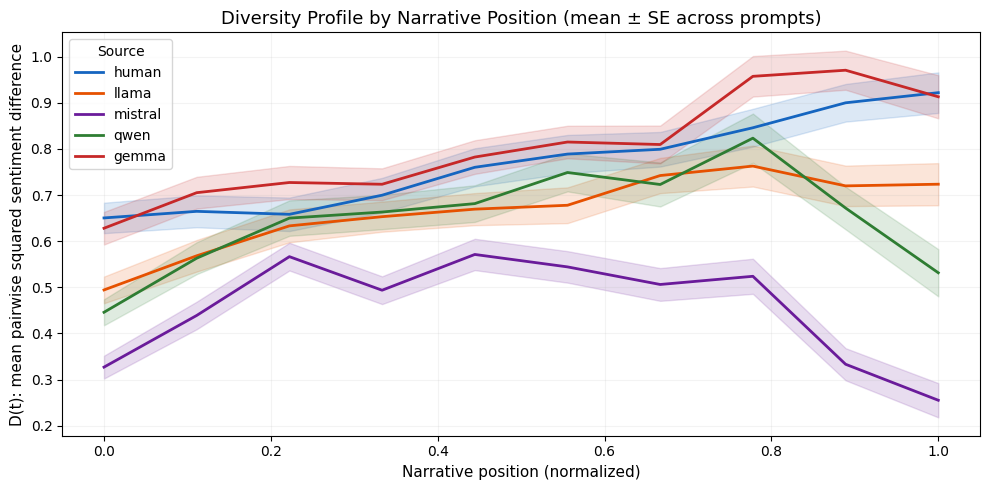

In [16]:
# Plot: diversity profile D(t) by narrative position, per source (mean ± SE across prompts)
x = np.linspace(0, 1, ARC_LENGTH)

fig, ax = plt.subplots(figsize=(10, 5))
for source in SOURCES:
    profiles = np.array(df_profile[df_profile['source'] == source]['profile'].tolist())
    mean_profile = profiles.mean(axis=0)
    se_profile = profiles.std(axis=0) / np.sqrt(len(profiles))
    color = SOURCE_COLORS[source]
    ax.plot(x, mean_profile, label=source, color=color, linewidth=2)
    ax.fill_between(x, mean_profile - se_profile, mean_profile + se_profile, alpha=0.15, color=color)

ax.set_xlabel('Narrative position (normalized)', fontsize=11)
ax.set_ylabel('D(t): mean pairwise squared sentiment difference', fontsize=11)
ax.set_title('Diversity Profile by Narrative Position (mean ± SE across prompts)', fontsize=13)
ax.legend(title='Source')
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig('../../figures/narrative_diversity/diversity_profile_by_position.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# Where in the story is diversity concentrated?
position_labels = np.linspace(0, 1, ARC_LENGTH)
third = ARC_LENGTH // 3

print('Narrative position of maximum diversity, by source:')
for source in SOURCES:
    profiles = np.array(df_profile[df_profile['source'] == source]['profile'].tolist())
    mean_profile = profiles.mean(axis=0)
    peak_idx = np.argmax(mean_profile)
    print(f'  {source:10s}: peak at position {position_labels[peak_idx]:.2f}  (D(t)={mean_profile[peak_idx]:.4f})')

print()
print('Diversity in the first third (setup) vs. last third (resolution) of the story:')
for source in SOURCES:
    profiles = np.array(df_profile[df_profile['source'] == source]['profile'].tolist())
    mean_profile = profiles.mean(axis=0)
    early = mean_profile[:third].mean()
    late = mean_profile[-third:].mean()
    print(f'  {source:10s}: early={early:.4f}, late={late:.4f}, ratio(early/late)={early / late:.2f}')

Narrative position of maximum diversity, by source:
  human     : peak at position 1.00  (D(t)=0.9220)
  llama     : peak at position 0.78  (D(t)=0.7628)
  mistral   : peak at position 0.44  (D(t)=0.5713)
  qwen      : peak at position 0.78  (D(t)=0.8234)
  gemma     : peak at position 0.89  (D(t)=0.9706)

Diversity in the first third (setup) vs. last third (resolution) of the story:
  human     : early=0.6578, late=0.8893, ratio(early/late)=0.74
  llama     : early=0.5653, late=0.7355, ratio(early/late)=0.77
  mistral   : early=0.4442, late=0.3708, ratio(early/late)=1.20
  qwen      : early=0.5531, late=0.6756, ratio(early/late)=0.82
  gemma     : early=0.6869, late=0.9470, ratio(early/late)=0.73


## Descriptive Analysis

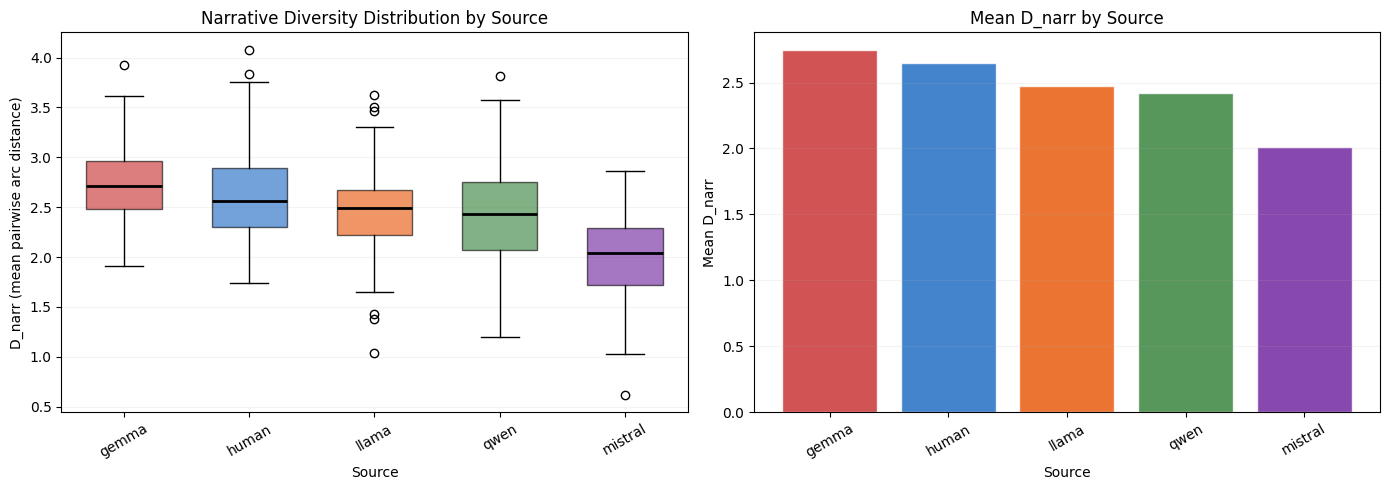

In [18]:
# D_narr by source
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

source_order = df_narr.groupby('source')['D_narr'].median().sort_values(ascending=False).index.tolist()

# Boxplot (patch_artist mit Source-Farben)
data = [df_narr[df_narr['source'] == s]['D_narr'].values for s in source_order]
bp = axes[0].boxplot(data, labels=source_order, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2), widths=0.6)
for patch, source in zip(bp['boxes'], source_order):
    patch.set_facecolor(SOURCE_COLORS[source])
    patch.set_alpha(0.6)
axes[0].set_title('Narrative Diversity Distribution by Source', fontsize=12)
axes[0].set_xlabel('Source')
axes[0].set_ylabel('D_narr (mean pairwise arc distance)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, alpha=0.15, axis='y')

# Mean D_narr
means = df_narr.groupby('source')['D_narr'].mean().reindex(source_order)
colors_bar = [SOURCE_COLORS[s] for s in source_order]
axes[1].bar(source_order, means.values, capsize=4,
            color=colors_bar, edgecolor='white', alpha=0.8)
axes[1].set_title('Mean D_narr by Source', fontsize=12)
axes[1].set_xlabel('Source')
axes[1].set_ylabel('Mean D_narr')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.15, axis='y')

plt.tight_layout()
plt.savefig('../../figures/narrative_diversity/narrative_by_source.png', dpi=300, bbox_inches='tight')
plt.show()

## Mean Sentiment Arcs per Source (Aggregate)

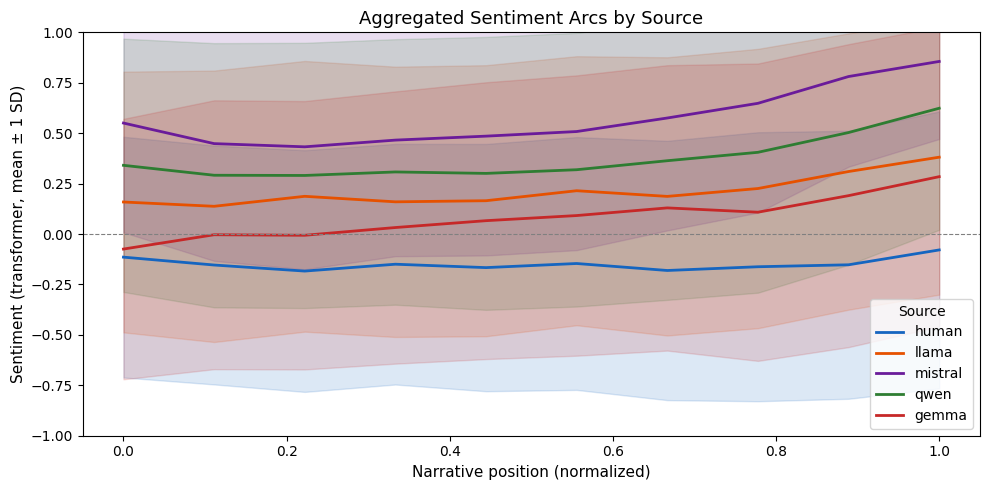

In [76]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.linspace(0, 1, ARC_LENGTH)

for source in SOURCES:
    source_arcs = df_valid[df_valid['source'] == source]['sentiment_arc'].tolist()
    if not source_arcs:
        continue
    mean_arc = np.mean(source_arcs, axis=0)
    std_arc  = np.std(source_arcs, axis=0)
    color = SOURCE_COLORS[source]
    ax.plot(x, mean_arc, label=source, color=color, linewidth=2)
    ax.fill_between(x, mean_arc - std_arc, mean_arc + std_arc, alpha=0.15, color=color)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Narrative position (normalized)', fontsize=11)
ax.set_ylabel('Sentiment (transformer, mean ± 1 SD)', fontsize=11)
ax.set_title('Aggregated Sentiment Arcs by Source', fontsize=13)
ax.legend(title='Source')
ax.set_ylim(-1, 1)
plt.tight_layout()
plt.savefig('../../figures/narrative_diversity/aggregated_sentiment_arcs.png', dpi=300, bbox_inches='tight')
plt.show()

## Arc-Shape-Classification

k-means with k=6 on all sentiment-arcs using the six basic forms of emotional arcs (Reagan et al., 2016): *Rags to Riches*, *Tragedy*, *Man in a Hole*, *Icarus*, *Cinderella*, *Oedipus*.

### Validating the Choice of k

check whether k=6 is actually well-supported by this dataset's own clustering structure:
1. Elbow method: inertia — always decreases with k, requires a subjective visual judgment of where returns diminish
2. Silhouette score: mean, over all points, of how much closer each point is to its own cluster than to the next-best cluster; ranges [-1, 1], forms an actual maximum rather than a subjective bend

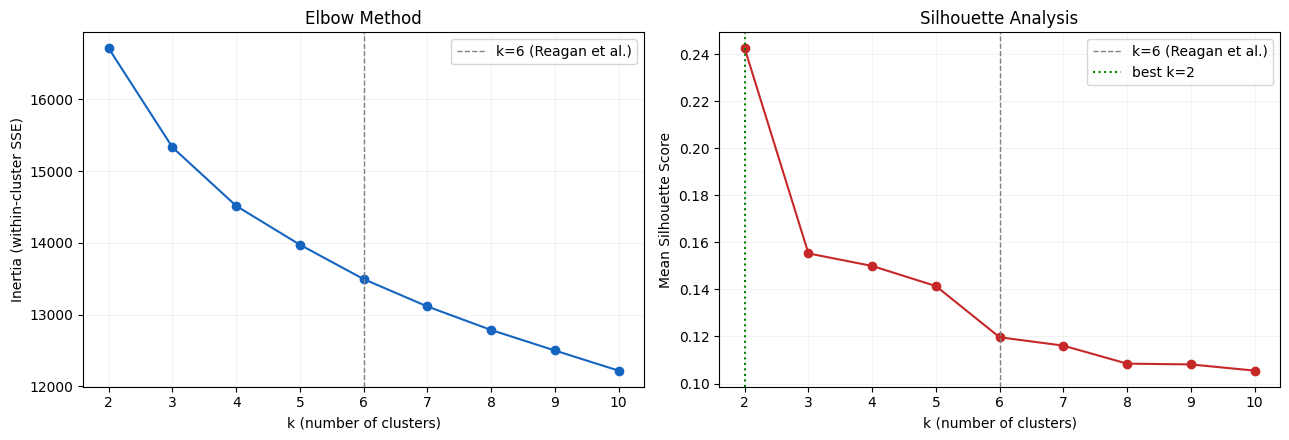

k, inertia, silhouette:
  k= 2: inertia=  16710.65, silhouette=0.2424
  k= 3: inertia=  15331.92, silhouette=0.1553
  k= 4: inertia=  14515.93, silhouette=0.1500
  k= 5: inertia=  13975.04, silhouette=0.1414
  k= 6: inertia=  13496.01, silhouette=0.1197
  k= 7: inertia=  13114.90, silhouette=0.1161
  k= 8: inertia=  12787.15, silhouette=0.1085
  k= 9: inertia=  12501.46, silhouette=0.1081
  k=10: inertia=  12221.07, silhouette=0.1055


In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

arc_matrix_check = np.array(df_valid['sentiment_arc'].tolist())

k_range = list(range(2, 11))
inertias = []
silhouettes = []

for k in k_range:
    # Fit KMeans
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(arc_matrix_check)
    # Compute inertia
    inertias.append(km.inertia_)
    # Compute silhouette score
    silhouettes.append(silhouette_score(arc_matrix_check, labels))

best_k = k_range[int(np.argmax(silhouettes))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(k_range, inertias, marker='o', color='#1565C0')
axes[0].axvline(6, color='gray', linestyle='--', linewidth=1, label='k=6 (Reagan et al.)')
axes[0].set_xlabel('k (number of clusters)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow Method')
axes[0].legend()
axes[0].grid(True, alpha=0.15)

axes[1].plot(k_range, silhouettes, marker='o', color='#C62828')
axes[1].axvline(6, color='gray', linestyle='--', linewidth=1, label='k=6 (Reagan et al.)')
axes[1].axvline(best_k, color='green', linestyle=':', linewidth=1.5, label=f'best k={best_k}')
axes[1].set_xlabel('k (number of clusters)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].legend()
axes[1].grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig('../../figures/narrative_diversity/kmeans_k_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print('k, inertia, silhouette:')
for k, inertia, sil in zip(k_range, inertias, silhouettes):
    print(f'  k={k:2d}: inertia={inertia:10.2f}, silhouette={sil:.4f}')

In [29]:
from sklearn.cluster import KMeans
from scipy.stats import entropy as scipy_entropy

np.random.seed(42)

# Arc-Matrix from all valid stories: each row is a story, each column is a point in the sentiment arc
arc_matrix = np.array(df_valid['sentiment_arc'].tolist())
df_valid = df_valid.reset_index(drop=True).copy()

# k-means with k=6
N_SHAPES = 6
kmeans = KMeans(n_clusters=N_SHAPES, random_state=42, n_init=20)
kmeans.fit(arc_matrix)
df_valid['arc_shape'] = kmeans.labels_

# Sort cluster by mean sentiment (positive to negative)
centroids = kmeans.cluster_centers_
shape_order = np.argsort(centroids.mean(axis=1))[::-1]
shape_remap = {int(old): int(new) for new, old in enumerate(shape_order)}
df_valid['arc_shape'] = df_valid['arc_shape'].map(shape_remap)
centroids = centroids[shape_order]

print(f'k-means with k={N_SHAPES} on {len(arc_matrix):,} sentiment-arcs')
print(f'\nCluster-Sizes:')
for i in range(N_SHAPES):
    n = (df_valid['arc_shape'] == i).sum()
    print(f'  Shape {i}: {n:4d} Stories ({n / len(df_valid) * 100:.1f}%)')

k-means with k=6 on 4,803 sentiment-arcs

Cluster-Sizes:
  Shape 0: 1188 Stories (24.7%)
  Shape 1:  685 Stories (14.3%)
  Shape 2:  717 Stories (14.9%)
  Shape 3:  634 Stories (13.2%)
  Shape 4:  773 Stories (16.1%)
  Shape 5:  806 Stories (16.8%)


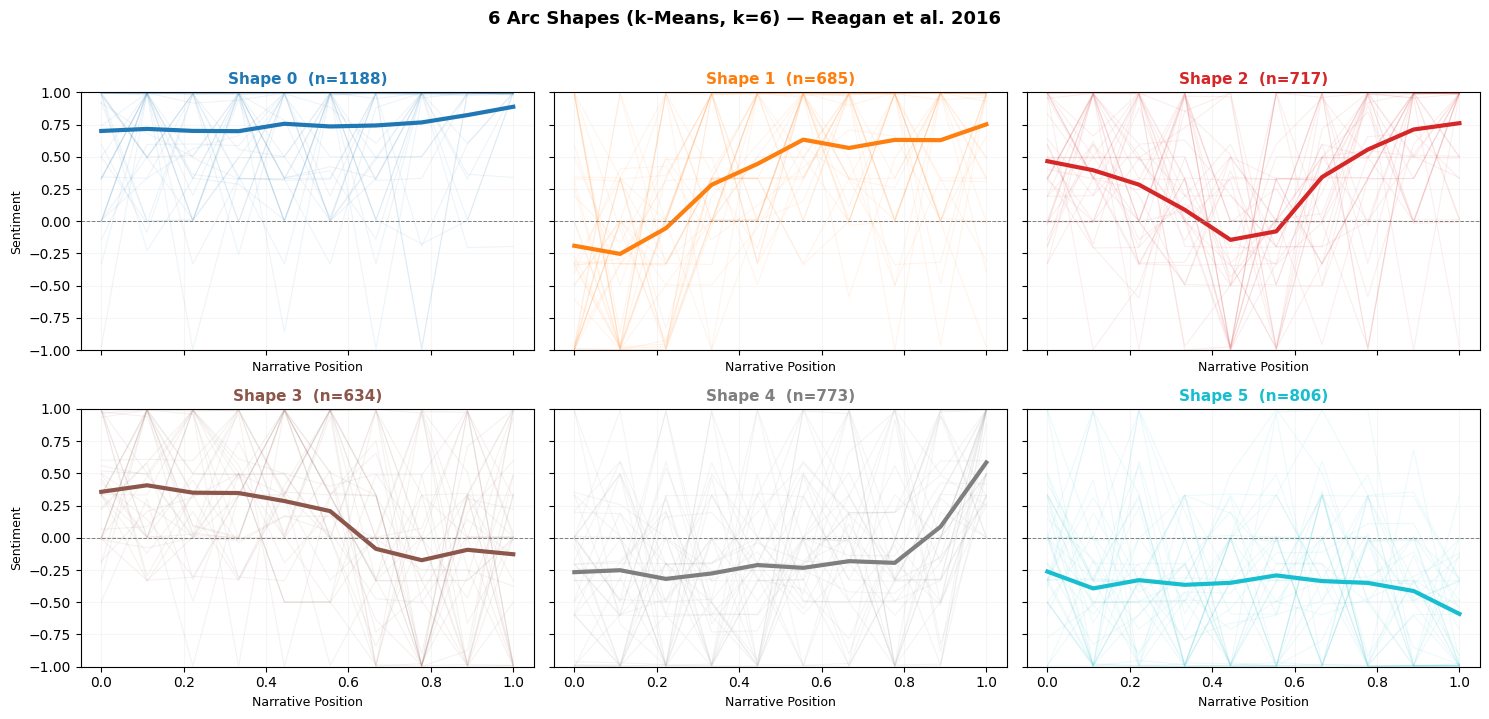

In [30]:
# Visualize 6 arc shapes: centroids + background arcs
SHAPE_COLORS = plt.cm.tab10(np.linspace(0, 0.9, N_SHAPES))
x = np.linspace(0, 1, ARC_LENGTH)

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True, sharex=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    mask = df_valid['arc_shape'] == i
    cluster_arcs = arc_matrix[mask.values]
    n_show = min(40, len(cluster_arcs))
    sample_idx = np.random.choice(len(cluster_arcs), n_show, replace=False)
    for arc in cluster_arcs[sample_idx]:
        ax.plot(x, arc, alpha=0.08, color=SHAPE_COLORS[i], linewidth=0.8)
    ax.plot(x, centroids[i], color=SHAPE_COLORS[i], linewidth=3)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.set_ylim(-1, 1)
    ax.set_title(f'Shape {i}  (n={mask.sum()})', fontsize=11, fontweight='bold',
                 color=SHAPE_COLORS[i])
    ax.set_xlabel('Narrative Position', fontsize=9)
    if i % 3 == 0:
        ax.set_ylabel('Sentiment', fontsize=9)
    ax.grid(True, alpha=0.1)

fig.suptitle('6 Arc Shapes (k-Means, k=6) — Reagan et al. 2016',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../figures/narrative_diversity/arc_shapes_kmeans.png', dpi=300, bbox_inches='tight')
plt.show()

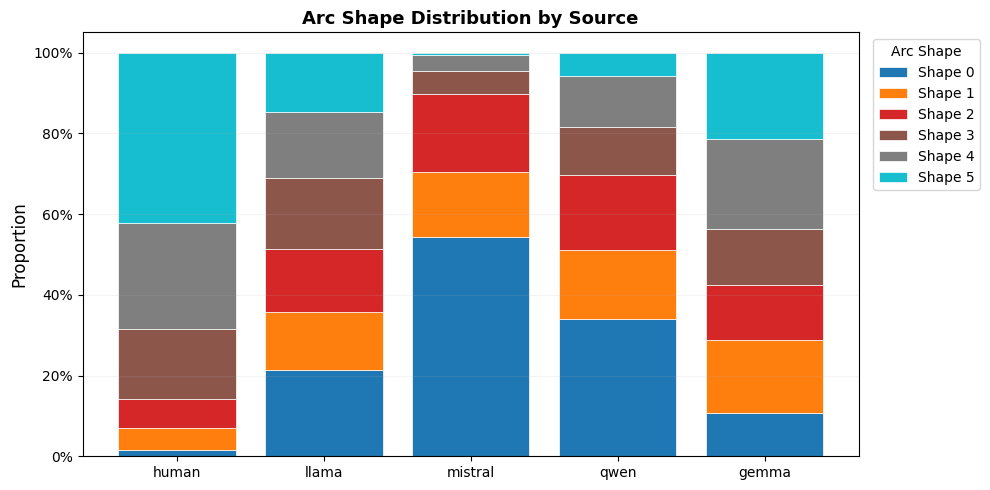

Entropy of arc shape distribution by source:
  (max. at uniform distribution: 2.585 bit)

  human     : H = 2.065 bit  ████████████████████
  llama     : H = 2.571 bit  █████████████████████████
  mistral   : H = 1.824 bit  ██████████████████
  qwen      : H = 2.397 bit  ███████████████████████
  gemma     : H = 2.537 bit  █████████████████████████


In [31]:
# Arc shape distribution by source (stacked bar chart)
from matplotlib.ticker import PercentFormatter

shape_dist = df_valid.groupby(['source', 'arc_shape']).size().unstack(fill_value=0)
shape_dist_norm = shape_dist.div(shape_dist.sum(axis=1), axis=0).reindex(SOURCES)

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(SOURCES))
for i in range(N_SHAPES):
    vals = shape_dist_norm[i].values
    ax.bar(SOURCES, vals, bottom=bottom, label=f'Shape {i}',
           color=SHAPE_COLORS[i], edgecolor='white', linewidth=0.5)
    bottom += vals
ax.set_ylabel('Proportion', fontsize=12)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title('Arc Shape Distribution by Source', fontsize=13, fontweight='bold')
ax.legend(title='Arc Shape', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
ax.grid(True, alpha=0.15, axis='y')
plt.tight_layout()
plt.savefig('../../figures/narrative_diversity/arc_shape_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Entropy of arc shape distribution by source
print('Entropy of arc shape distribution by source:')
print(f'  (max. at uniform distribution: {np.log2(N_SHAPES):.3f} bit)')
print()
for source in SOURCES:
    dist = shape_dist_norm.loc[source].values
    ent = scipy_entropy(dist, base=2)
    bar = '█' * int(ent * 10)
    print(f'  {source:10s}: H = {ent:.3f} bit  {bar}')

## Which Source Prefers Which Arc Shape?

In [37]:
from scipy.stats import chi2_contingency

# Aggregate to one arc-shape per (prompt, source) group to avoid pseudo-replication
group_mean_arcs = (
    df_valid.groupby(['prompt_id', 'source'])['sentiment_arc']
    .apply(lambda g: np.mean(np.array(g.tolist()), axis=0))
)
valid_keys = set(zip(df_narr['prompt_id'], df_narr['source']))
group_mean_arcs = group_mean_arcs[[k in valid_keys for k in group_mean_arcs.index]]

mean_arc_matrix = np.stack(group_mean_arcs.values)
mean_labels_raw = kmeans.predict(mean_arc_matrix)
mean_labels = np.array([shape_remap[int(l)] for l in mean_labels_raw])

shape_group = pd.DataFrame({
    'prompt_id': [k[0] for k in group_mean_arcs.index],
    'source': [k[1] for k in group_mean_arcs.index],
    'arc_shape': mean_labels,
})

shape_dist_agg = (
    shape_group.groupby(['source', 'arc_shape']).size()
    .unstack(fill_value=0)
    .reindex(index=SOURCES, columns=range(N_SHAPES), fill_value=0)
)

print(f"Aggregated {len(df_valid)} individual stories -> {len(shape_group)} (prompt, source) groups.")
print(shape_dist_agg)

# Chi-square test of independence on the aggregated (independent) groups
chi2_agg, p_chi2_agg, dof_agg, expected_agg = chi2_contingency(shape_dist_agg.values)
cramers_v_agg = np.sqrt(chi2_agg / (shape_dist_agg.values.sum() * (min(shape_dist_agg.shape) - 1)))

print("\nChi-square test of independence (source x arc shape), prompt-level aggregated:")
print(f"  N = {shape_dist_agg.values.sum()}, chi2 = {chi2_agg:.2f}, dof = {dof_agg}, p = {p_chi2_agg:.2e}")
print(f"  Cramer's V = {cramers_v_agg:.3f}")

# For comparison: the naive test on all individual (pseudo-replicated) stories
chi2, p_chi2, dof, expected = chi2_contingency(shape_dist.values)
cramers_v = np.sqrt(chi2 / (shape_dist.values.sum() * (min(shape_dist.shape) - 1)))
print(f"  chi2 = {chi2:.2f}, dof = {dof}, p = {p_chi2:.2e}, Cramer's V = {cramers_v:.3f}")

# Standardized residuals on the aggregated table: (observed - expected) / sqrt(expected)
# Positive = source uses this shape more than chance, negative = less
std_resid = (shape_dist_agg.values - expected_agg) / np.sqrt(expected_agg)
df_resid = pd.DataFrame(std_resid, index=shape_dist_agg.index, columns=shape_dist_agg.columns)
df_resid.columns = [f'Shape {i}' for i in df_resid.columns]

print("\nStandardized residuals (source x shape), prompt-level aggregated:")
print(df_resid.round(2))

Aggregated 4803 individual stories -> 491 (prompt, source) groups.
arc_shape   0   1   2   3   4   5
source                           
human       0   1   3  15  33  48
llama      23   8  20  14  25   9
mistral    62  15  18   2   2   0
qwen       35  12  24  10  12   3
gemma       9  15  13  13  28  19

Chi-square test of independence (source x arc shape), prompt-level aggregated:
  N = 491, chi2 = 257.04, dof = 20, p = 4.34e-43
  Cramer's V = 0.362
  chi2 = 1642.26, dof = 20, p = 0.00e+00, Cramer's V = 0.292

Standardized residuals (source x shape), prompt-level aggregated:
         Shape 0  Shape 1  Shape 2  Shape 3  Shape 4  Shape 5
source                                                       
human      -5.13    -2.91    -3.23     1.21     2.80     7.96
llama      -0.59    -0.71     1.08     0.94     1.08    -1.74
mistral     7.06     1.47     0.57    -2.69    -4.04    -3.99
qwen        1.95     0.64     2.24    -0.17    -1.71    -3.17
gemma      -3.27     1.55    -0.61     0.71  

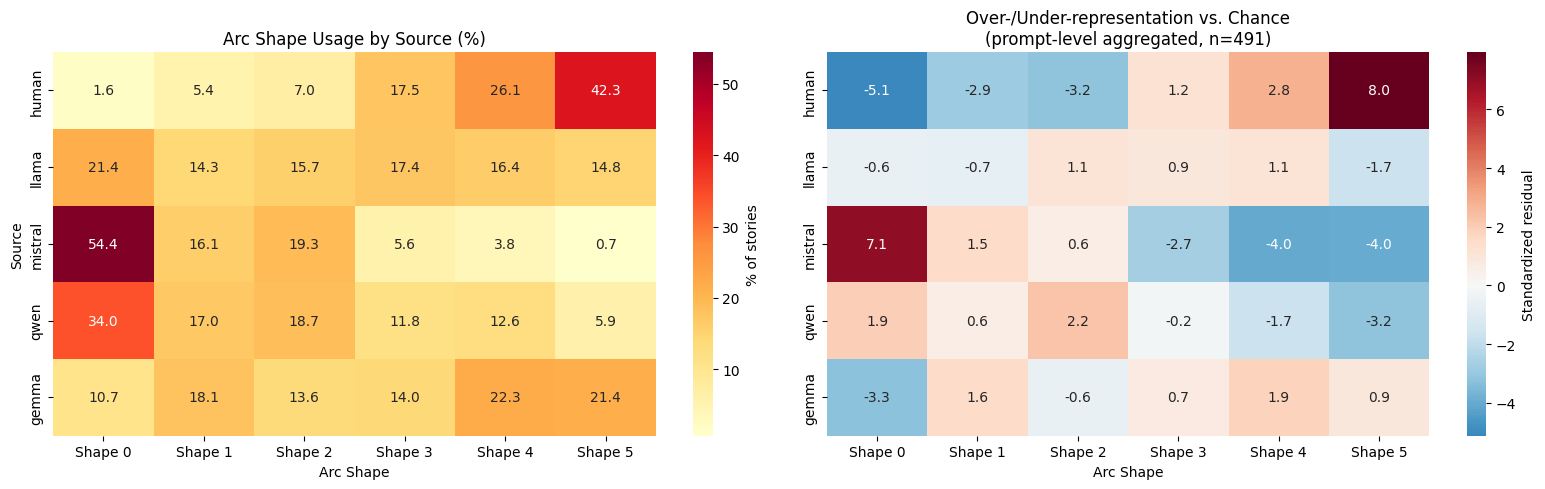

In [38]:
# Heatmaps: usage share and over-/under-representation vs. chance
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(shape_dist_norm * 100, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': '% of stories'}, ax=axes[0],
            xticklabels=[f'Shape {i}' for i in range(N_SHAPES)])
axes[0].set_title('Arc Shape Usage by Source (%)', fontsize=12)
axes[0].set_xlabel('Arc Shape')
axes[0].set_ylabel('Source')

sns.heatmap(df_resid, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Standardized residual'}, ax=axes[1])
axes[1].set_title('Over-/Under-representation vs. Chance\n(prompt-level aggregated, n=491)', fontsize=12)
axes[1].set_xlabel('Arc Shape')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../../figures/narrative_diversity/arc_shape_source_association.png', dpi=300, bbox_inches='tight')
plt.show()

In [39]:
# Dominant arc shape per source
print('Dominant arc shape per source:')
print(f'{"Source":10s} {"Dominant Shape":>15} {"Share":>8} {"vs. chance (16.7%)":>20}')
print('-' * 60)
for source in SOURCES:
    dist = shape_dist_norm.loc[source]
    dominant = dist.idxmax()
    share = dist.max()
    delta_pp = (share - 1 / N_SHAPES) * 100
    print(f'{source:10s} {"Shape " + str(dominant):>15} {share * 100:>7.1f}% {delta_pp:>+19.1f}pp')

Dominant arc shape per source:
Source      Dominant Shape    Share   vs. chance (16.7%)
------------------------------------------------------------
human              Shape 5    42.3%               +25.6pp
llama              Shape 0    21.4%                +4.8pp
mistral            Shape 0    54.4%               +37.8pp
qwen               Shape 0    34.0%               +17.3pp
gemma              Shape 4    22.3%                +5.6pp


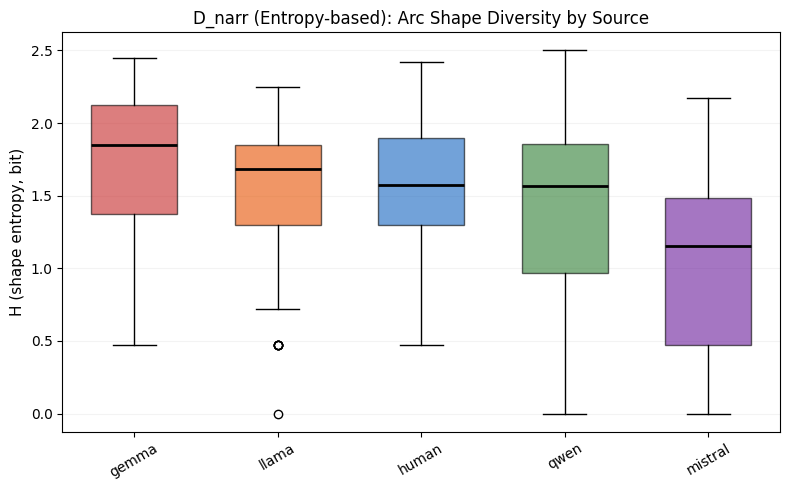

Correlation D_narr (distance) ↔ D_narr (entropy):
  Pearson r = 0.633

Mean shape entropy by source:
  human     : 1.576 ± 0.412 bit
  llama     : 1.532 ± 0.497 bit
  mistral   : 1.077 ± 0.616 bit
  qwen      : 1.424 ± 0.630 bit
  gemma     : 1.705 ± 0.445 bit


In [40]:
# Entropy-based D_narr per (prompt, source)
def shape_entropy(group):
    counts = group['arc_shape'].value_counts()
    return scipy_entropy((counts / counts.sum()).values, base=2)

entropy_results = (
    df_valid.groupby(['prompt_id', 'source'])
    .apply(shape_entropy)
    .reset_index(name='D_narr_entropy')
)

# Restrict to the same non-degenerate groups as D_narr (inner join on the already-filtered df_narr).
entropy_results = entropy_results.merge(df_narr[['prompt_id', 'source']], on=['prompt_id', 'source'])

# Boxplot: entropy-based D_narr by source
fig, ax = plt.subplots(figsize=(8, 5))
ent_order = (entropy_results.groupby('source')['D_narr_entropy']
             .median().sort_values(ascending=False).index.tolist())
data_ent = [entropy_results[entropy_results['source'] == s]['D_narr_entropy'].values
            for s in ent_order]
bp = ax.boxplot(data_ent, labels=ent_order, patch_artist=True,
                medianprops=dict(color='black', linewidth=2), widths=0.6)
for patch, source in zip(bp['boxes'], ent_order):
    patch.set_facecolor(SOURCE_COLORS[source])
    patch.set_alpha(0.6)
ax.set_title('D_narr (Entropy-based): Arc Shape Diversity by Source', fontsize=12)
ax.set_ylabel('H (shape entropy, bit)', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.15, axis='y')
plt.tight_layout()
plt.show()

# Correlation with distance-based D_narr
merged = df_narr[['prompt_id', 'source', 'D_narr']].merge(
    entropy_results, on=['prompt_id', 'source']
)
r = np.corrcoef(merged['D_narr'], merged['D_narr_entropy'])[0, 1]
print(f'Correlation D_narr (distance) ↔ D_narr (entropy):')
print(f'  Pearson r = {r:.3f}')
print()
print('Mean shape entropy by source:')
for source in SOURCES:
    vals = entropy_results[entropy_results['source'] == source]['D_narr_entropy']
    print(f'  {source:10s}: {vals.mean():.3f} ± {vals.std():.3f} bit')

## Statistical Testing: Does Source Affect D_narr?

In [41]:
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations as combos

groups = [df_narr[df_narr['source'] == s]['D_narr'].values for s in SOURCES]

# Kruskal-Wallis (non-parametric ANOVA alternative)
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis test across sources:")
print(f"  H = {stat:.4f}, p = {p:.4f}")
print("  -> Significant difference in D_narr across sources (p < 0.05)")

print("\nPairwise Mann-Whitney U tests (Bonferroni corrected):")
pairs = list(combos(SOURCES, 2))
alpha_corrected = 0.05 / len(pairs)
print(f"  Bonferroni threshold: p < {alpha_corrected:.4f}")

for s1, s2 in pairs:
    g1 = df_narr[df_narr['source'] == s1]['D_narr'].values
    g2 = df_narr[df_narr['source'] == s2]['D_narr'].values
    u, p_mw = mannwhitneyu(g1, g2, alternative='two-sided')
    sig = '***' if p_mw < alpha_corrected else ('*' if p_mw < 0.05 else 'ns')
    print(f"  {s1:10s} vs {s2:10s}: U={u:.0f}, p={p_mw:.4f}  {sig}")

Kruskal-Wallis test across sources:
  H = 120.5301, p = 0.0000
  -> Significant difference in D_narr across sources (p < 0.05)

Pairwise Mann-Whitney U tests (Bonferroni corrected):
  Bonferroni threshold: p < 0.0050
  human      vs llama     : U=5824, p=0.0315  *
  human      vs mistral   : U=8343, p=0.0000  ***
  human      vs qwen      : U=5845, p=0.0085  *
  human      vs gemma     : U=3969, p=0.0277  *
  llama      vs mistral   : U=7661, p=0.0000  ***
  llama      vs qwen      : U=5020, p=0.4972  ns
  llama      vs gemma     : U=3030, p=0.0000  ***
  mistral    vs qwen      : U=2549, p=0.0000  ***
  mistral    vs gemma     : U=934, p=0.0000  ***
  qwen       vs gemma     : U=2872, p=0.0000  ***


## Effect Size: Human vs. LLM

In [42]:
def cohens_d(a, b):
    "Compute Cohen's d effect size between two arrays"
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * a.std()**2 + (nb - 1) * b.std()**2) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else 0

print('Effect Size Human vs. Model for D_narr')
print(f'{"Model":<10} {"Cohen d":>10} {"Strength":>10} {"U-test p":>12}')
print('-' * 46)
h = df_narr[df_narr['source'] == 'human']['D_narr'].values
for source in SOURCES[1:]:
    m = df_narr[df_narr['source'] == source]['D_narr'].values
    d = cohens_d(h, m)
    _, p_val = mannwhitneyu(h, m, alternative='two-sided')
    strength = 'large' if abs(d) > 0.8 else 'medium' if abs(d) > 0.5 else 'small'
    print(f'{source:<10} {d:>+10.3f} {strength:>10} {p_val:>12.2e}')

Effect Size Human vs. Model for D_narr
Model         Cohen d   Strength     U-test p
----------------------------------------------
llama          +0.387      small     3.15e-02
mistral        +1.407      large     6.73e-17
qwen           +0.471      small     8.51e-03
gemma          -0.218      small     2.77e-02


## Diversity Gap (Human, Model)

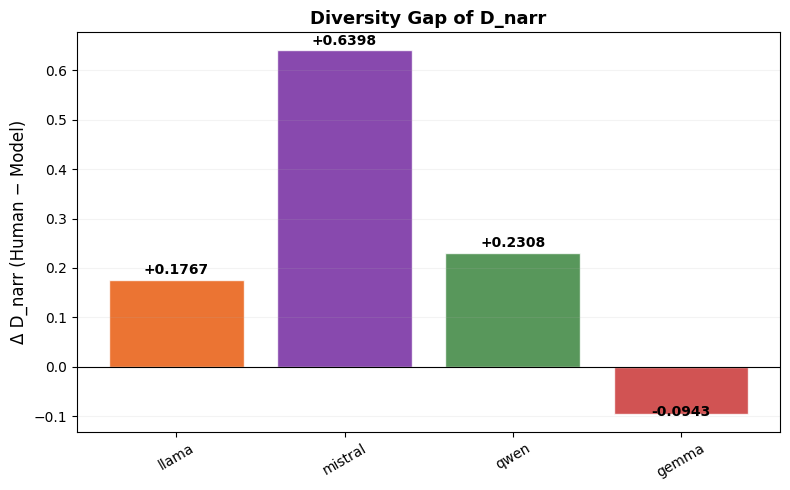


Diversity Gap (Human − Model):
  llama     : +0.1767
  mistral   : +0.6398
  qwen      : +0.2308
  gemma     : -0.0943


In [43]:
human_mean = df_narr[df_narr['source'] == 'human']['D_narr'].mean()
llm_sources = SOURCES[1:]

deltas = [
    human_mean - df_narr[df_narr['source'] == s]['D_narr'].mean()
    for s in llm_sources
]
colors_gap = [SOURCE_COLORS[s] for s in llm_sources]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(llm_sources, deltas, color=colors_gap, alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Δ D_narr (Human − Model)', fontsize=12)
ax.set_title('Diversity Gap of D_narr', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.15, axis='y')

for bar, delta in zip(bars, deltas):
    ax.text(bar.get_x() + bar.get_width() / 2, delta + (0.005 if delta >= 0 else -0.012),
            f'{delta:+.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../../figures/narrative_diversity/diversity_gap_human_model.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nDiversity Gap (Human − Model):')
for s, d in zip(llm_sources, deltas):
    print(f'  {s:10s}: {d:+.4f}')

# Appendix: VADER-based Sentiment Arcs (for Reference)

analysis above uses a transformer-based sentiment classifier (`siebert/sentiment-roberta-large-english`) as sentiment signal 
-> original VADER-based pipeline on the same texts and compares its D_narr against the transformer-based D_narr reported above

In [93]:
# Recompute sentiment arcs with VADER (original lexicon-based approach) for reference
vader_analyzer = SentimentIntensityAnalyzer()

def get_sentiment_arc_vader(text: str, arc_length: int = ARC_LENGTH, min_sentences: int = MIN_SENTENCES):
    """VADER-based sentiment arc, kept for reference/comparison with the transformer pipeline above."""
    sentences = sent_tokenize(text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 5]
    if len(sentences) < min_sentences:
        return None
    scores = [vader_analyzer.polarity_scores(s)['compound'] for s in sentences]
    return bin_to_arc(scores, arc_length)

df['sentiment_arc_vader'] = df['text'].apply(get_sentiment_arc_vader)
df_valid_vader = df.dropna(subset=['sentiment_arc_vader']).copy()
print(f"Valid VADER arcs: {len(df_valid_vader)}")

Valid VADER arcs: 4803


In [94]:
# D_narr with VADER arcs, for comparison against the transformer-based D_narr above
results_vader = []
for (prompt_id, source), group in df_valid_vader.groupby(['prompt_id', 'source']):
    arcs = group['sentiment_arc_vader'].tolist()
    d_narr = mean_pairwise_l2(arcs)
    results_vader.append({
        'prompt_id': prompt_id,
        'source': source,
        'n_stories': len(arcs),
        'D_narr_vader': d_narr
    })

df_narr_vader = pd.DataFrame(results_vader)
df_narr_vader = df_narr_vader[df_narr_vader['n_stories'] >= MIN_STORIES_PER_GROUP].reset_index(drop=True)
print("D_narr (VADER) by source:")
print(df_narr_vader.groupby('source')['D_narr_vader'].describe().round(4))

comparison_vader = df_narr.merge(df_narr_vader, on=['prompt_id', 'source'])
r_vader = np.corrcoef(comparison_vader['D_narr'], comparison_vader['D_narr_vader'])[0, 1]
print(f"\nCorrelation D_narr (transformer) <-> D_narr (VADER): r = {r_vader:.3f}")

D_narr (VADER) by source:
         count    mean     std     min     25%     50%     75%     max
source                                                                
gemma     97.0  1.0299  0.2014  0.6361  0.9005  1.0030  1.1838  1.5783
human    100.0  1.0176  0.2343  0.6479  0.8470  0.9639  1.1280  1.6375
llama     99.0  1.0018  0.2441  0.5467  0.8367  0.9569  1.1610  1.9918
mistral   99.0  1.1103  0.2198  0.7490  0.9607  1.0857  1.2334  2.0478
qwen      96.0  1.0267  0.2260  0.5129  0.8397  1.0129  1.1752  1.5815

Correlation D_narr (transformer) <-> D_narr (VADER): r = 0.225


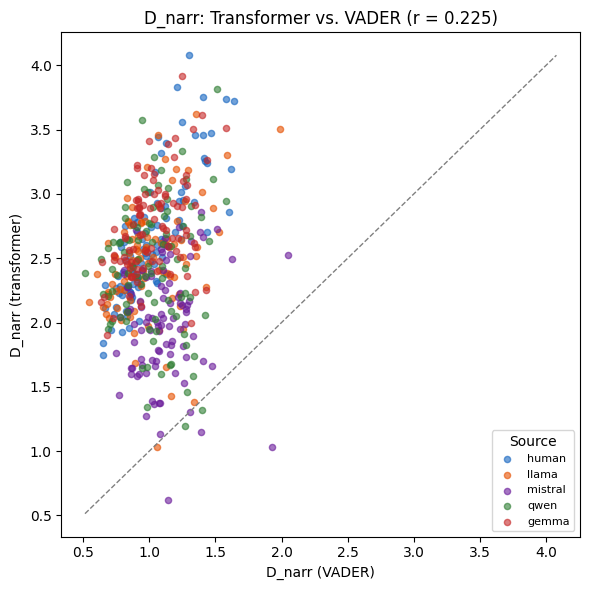

In [96]:
# Visual comparison: D_narr (transformer) vs. D_narr (VADER), per (prompt, source)
fig, ax = plt.subplots(figsize=(6, 6))
for source in SOURCES:
    sub = comparison_vader[comparison_vader['source'] == source]
    ax.scatter(sub['D_narr_vader'], sub['D_narr'], color=SOURCE_COLORS[source], alpha=0.6, label=source, s=20)

lims = [comparison_vader[['D_narr', 'D_narr_vader']].min().min(),
        comparison_vader[['D_narr', 'D_narr_vader']].max().max()]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('D_narr (VADER)')
ax.set_ylabel('D_narr (transformer)')
ax.set_title(f'D_narr: Transformer vs. VADER (r = {r_vader:.3f})')
ax.legend(title='Source', fontsize=8)
plt.tight_layout()
plt.savefig('../../figures/narrative_diversity/d_narr_transformer_vs_vader.png', dpi=300, bbox_inches='tight')
plt.show()